# **Exploratory Data Analysis**
---

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

USE_MOCK_DATA = True

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from src.config import load_config
from src.paths import get_paths
from src.visualization import set_publication_style, save_figure

cfg   = load_config()
paths = get_paths()
set_publication_style()

manifest = pd.read_csv(paths["interim"] / "manifest_clean.csv")
print(f"Loaded cleaned manifest: {manifest.shape}")
print(manifest.head())

Loaded cleaned manifest: (800, 5)
                                          image_path  label     dataset  \
0  C:\Users\Peter\Documents\projects\Data_science...      0  montgomery   
1  C:\Users\Peter\Documents\projects\Data_science...      0  montgomery   
2  C:\Users\Peter\Documents\projects\Data_science...      0  montgomery   
3  C:\Users\Peter\Documents\projects\Data_science...      0  montgomery   
4  C:\Users\Peter\Documents\projects\Data_science...      0  montgomery   

   original_filename                        image_hash  
0  MCUCXR_0001_0.png  ca44652f0bfd367b751c347ce9dae047  
1  MCUCXR_0002_0.png  d6007bea9d2dce90fcc3efad868015b7  
2  MCUCXR_0003_0.png  d630192fed69da737a8ca32ca032189b  
3  MCUCXR_0004_0.png  eaa96045832817dd74f61cfbcfd5d38e  
4  MCUCXR_0005_0.png  0a5c485bd81f1647d67b0b9ff5cbf7ac  


## Class Distribution

Figure saved: 'class_distribution.png' and 'class_distribution.pdf'


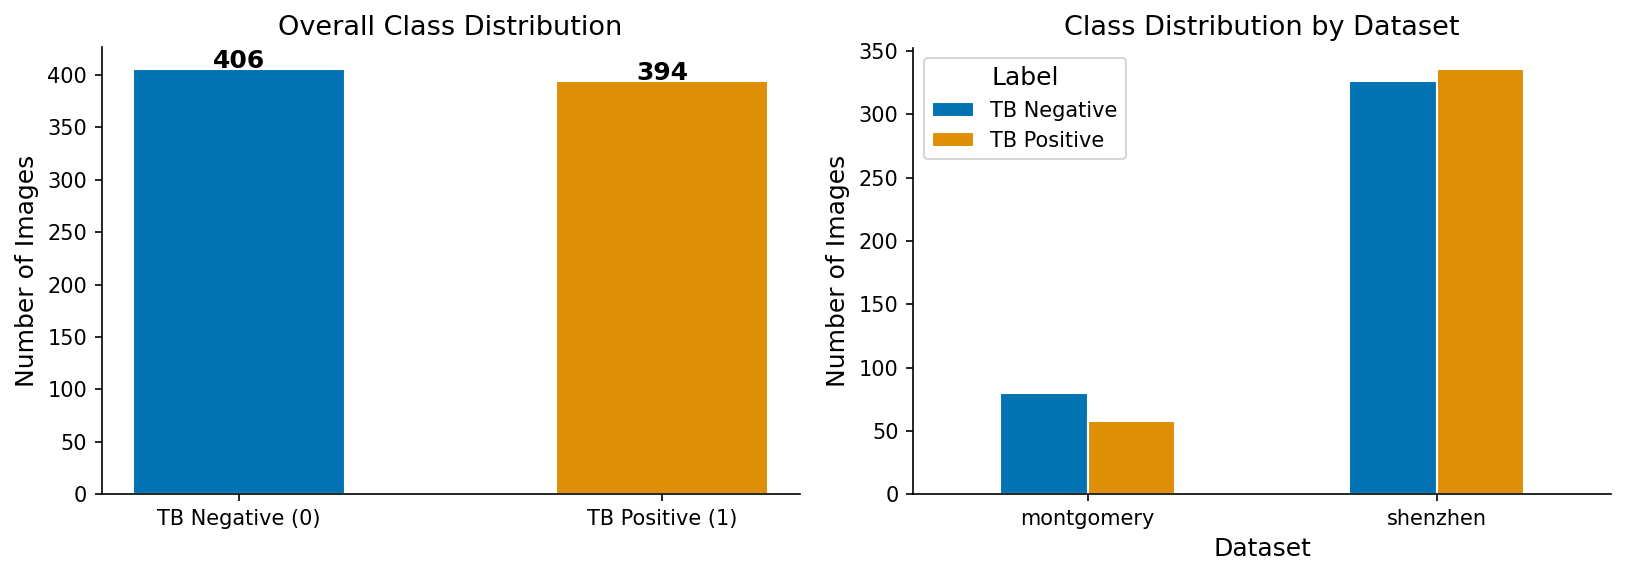

TB Positive rate: 49.2%
Classes are roughly balanced. Class weighting is optional but still recommended.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: overall class distribution
counts = manifest["label"].value_counts().sort_index()
labels_txt = ["TB Negative (0)", "TB Positive (1)"]
colors = sns.color_palette("colorblind", 2)
axes[0].bar(labels_txt, counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Overall Class Distribution")
axes[0].set_ylabel("Number of Images")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha="center", fontweight="bold")

# Right: by dataset if multiple datasets present
if "dataset" in manifest.columns:
    crosstab = pd.crosstab(manifest["dataset"], manifest["label"])
    crosstab.columns = ["TB Negative", "TB Positive"]
    crosstab.plot(kind="bar", ax=axes[1], color=colors, edgecolor="white")
    axes[1].set_title("Class Distribution by Dataset")
    axes[1].set_ylabel("Number of Images")
    axes[1].set_xlabel("Dataset")
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].legend(title="Label")
else:
    axes[1].axis("off")

plt.tight_layout()
save_figure(fig, "class_distribution", paths["figures"], paths["paper_figures"])
plt.show()

# Interpretation
pos_rate = 100 * (manifest["label"] == 1).mean()
print(f"TB Positive rate: {pos_rate:.1f}%")
if pos_rate < 40 or pos_rate > 60:
    print("I note a class imbalance. I will use class-weighted loss during training.")
else:
    print("Classes are roughly balanced. Class weighting is optional but still recommended.")

## Pixel Intensity Statistics

I computed mean and standard deviation of each image's pixel values.
This helps me understand: 
- Are TB-positive CXRs systematically brighter or darker?
- What normalisation parameters are appropriate?

In [3]:
print("Computing pixel statistics for each image (may take ~1 minute for real data)...")

stats_rows = []
sample_limit = min(len(manifest), 200)  # Limit sample for speed with mock data

for _, row in manifest.sample(n=sample_limit, random_state=42).iterrows():
    try:
        img_array = np.array(Image.open(row["image_path"]).convert("L"), dtype=np.float32)
        stats_rows.append({
            "image_path": row["image_path"],
            "label":      row["label"],
            "dataset":    row.get("dataset", "unknown"),
            "mean_intensity":   float(img_array.mean()),
            "std_intensity":    float(img_array.std()),
            "min_intensity":    float(img_array.min()),
            "max_intensity":    float(img_array.max()),
            "width":  img_array.shape[1],
            "height": img_array.shape[0],
        })
    except Exception as e:
        print(f"  Skipping {row['image_path']}: {e}")

stats_df = pd.DataFrame(stats_rows)
print(f"Computed statistics for {len(stats_df)} images.")
print()
print("Summary by label:")
print(stats_df.groupby("label")[["mean_intensity","std_intensity"]].describe().round(2))

Computing pixel statistics for each image (may take ~1 minute for real data)...
Computed statistics for 200 images.

Summary by label:
      mean_intensity                                                         \
               count    mean    std     min     25%     50%     75%     max   
label                                                                         
0               97.0  151.65  21.99  101.52  136.90  155.16  168.91  191.84   
1              103.0  146.70  19.21   81.71  142.31  148.27  156.90  184.40   

      std_intensity                                                   
              count   mean    std    min    25%    50%    75%    max  
label                                                                 
0              97.0  67.11  11.46  48.04  59.56  65.09  73.58  94.49  
1             103.0  67.44   8.22  50.85  62.59  65.44  69.54  92.76  


Figure saved: 'pixel_intensity_distributions.png' and 'pixel_intensity_distributions.pdf'


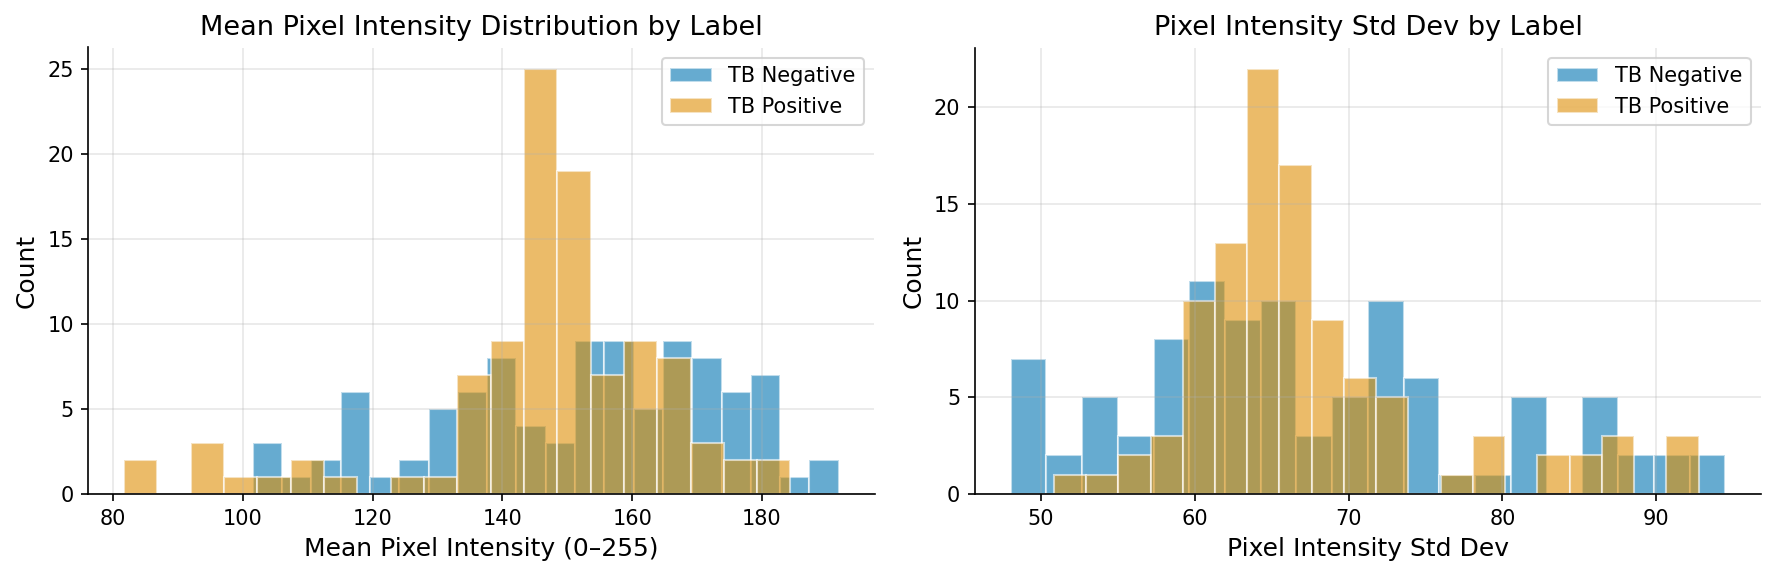

Interpretation:
  TB Negative: mean pixel intensity = 151.7
  TB Positive: mean pixel intensity = 146.7

If TB-positive images are systematically brighter/darker,
this is a potential confound the model might exploit instead of
learning true pathological features. I will monitor for this in notebook 12.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = sns.color_palette("colorblind", 2)
label_names = {0: "TB Negative", 1: "TB Positive"}

# Mean intensity distribution by label
for label_val in [0, 1]:
    subset = stats_df[stats_df["label"] == label_val]["mean_intensity"]
    axes[0].hist(subset, bins=20, alpha=0.6, label=label_names[label_val],
                 color=colors[label_val], edgecolor="white")
axes[0].set_xlabel("Mean Pixel Intensity (0–255)")
axes[0].set_ylabel("Count")
axes[0].set_title("Mean Pixel Intensity Distribution by Label")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Std intensity distribution by label
for label_val in [0, 1]:
    subset = stats_df[stats_df["label"] == label_val]["std_intensity"]
    axes[1].hist(subset, bins=20, alpha=0.6, label=label_names[label_val],
                 color=colors[label_val], edgecolor="white")
axes[1].set_xlabel("Pixel Intensity Std Dev")
axes[1].set_ylabel("Count")
axes[1].set_title("Pixel Intensity Std Dev by Label")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
save_figure(fig, "pixel_intensity_distributions", paths["figures"], paths["paper_figures"])
plt.show()

# Interpretation
print("Interpretation:")
for label_val, label_name in label_names.items():
    mean_int = stats_df[stats_df["label"]==label_val]["mean_intensity"].mean()
    print(f"  {label_name}: mean pixel intensity = {mean_int:.1f}")
print()
print("If TB-positive images are systematically brighter/darker,")
print("this is a potential confound the model might exploit instead of")
print("learning true pathological features. I will monitor for this in notebook 12.")

In [5]:
# Save EDA summary table
eda_summary = stats_df.groupby("label")[["mean_intensity","std_intensity","width","height"]].agg(
    ["mean","std","min","max"]
).round(2)

eda_path = paths["tables"] / "eda_summary.csv"
eda_summary.to_csv(eda_path)
print(f"EDA summary saved: {eda_path}")

EDA summary saved: C:\Users\Peter\Documents\projects\Data_science\fedtb_nigeria\reports\tables\eda_summary.csv
